### 1.1 Import Libraries & Configure Environment
We start by importing essential libraries and setting a global random seed to ensure reproducibility.

# PHASE 1: Data Acquisition & Environment Setup
**Traceability**
- Dataset DOI: [10.1109/PHM.2008.4711411](https://doi.org/10.1109/PHM.2008.4711411)
- Issue ID: #1 Data Acquisition & Environment Setup

**External References**:
- [Carl Kirstein - Predictive Maintenance](https://www.kaggle.com/code/carlkirstein/predictive-maintenance-nasa-turbofan-regression) (Data Loading logic)
- [Wassim Derbel - NASA Predictive Maintenance](https://www.kaggle.com/code/wassimderbel/nasa-predictive-maintenance-rul) (Schema Validation)

## 1. Objectives
- Establish a reproducible environment for NASA CMAPSS analysis.
- Load the NASA CMAPSS FD001 dataset (train, test, and RUL ground truth).
- Validate the schema to ensure data quality and prevent downstream errors.
- **Evidence-based decision making**: Inspect raw data format before parsing.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Reproducibility Config ──────────────────────────────────────────────
np.random.seed(42)

# ── Plotting Config ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

# ── Global Config ────────────────────────────────────────────────────────
DATA_DIR = Path('../data')
COL_NAMES = (
    ['unit_number', 'time_cycles'] +
    ['setting_1', 'setting_2', 'setting_3'] +
    [f's_{i}' for i in range(1, 22)]   # s_1 ... s_21
)

### 1.2 Raw Data Inspection
Before loading the data into pandas, we inspect the raw text file to confirm the delimiter and structure. This justifies our choice of `sep=r'\s+'`.

In [2]:
# Diagnostic: Peek at the first 3 lines of the raw file
with open(DATA_DIR / 'train_FD001.txt', 'r') as f:
    print("--- Raw File Content (First 3 lines) ---")
    for _ in range(3):
        print(f.readline().strip())

--- Raw File Content (First 3 lines) ---
1 1 -0.0007 -0.0004 100.0 518.67 641.82 1589.70 1400.60 14.62 21.61 554.36 2388.06 9046.19 1.30 47.47 521.66 2388.02 8138.62 8.4195 0.03 392 2388 100.00 39.06 23.4190
1 2 0.0019 -0.0003 100.0 518.67 642.15 1591.82 1403.14 14.62 21.61 553.75 2388.04 9044.07 1.30 47.49 522.28 2388.07 8131.49 8.4318 0.03 392 2388 100.00 39.00 23.4236
1 3 -0.0043 0.0003 100.0 518.67 642.35 1587.99 1404.20 14.62 21.61 554.26 2388.08 9052.94 1.30 47.27 522.42 2388.03 8133.23 8.4178 0.03 390 2388 100.00 38.95 23.3442


**Reasoning**: The output shows space-separated values without a header. Therefore, we must use `sep=r'\s+'` and manually assign `header=None` and column names.

In [3]:
def load_dataset(filename):
    """Load whitespace-separated text file into a DataFrame."""
    path = DATA_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f"Dataset file not found: {path}")
    
    df = pd.read_csv(
        path,
        sep=r'\s+', header=None, index_col=False, names=COL_NAMES
    )
    return df

# Load Data
df_train = load_dataset('train_FD001.txt')
df_test = load_dataset('test_FD001.txt')
df_rul = load_dataset('RUL_FD001.txt')
print(f"✅ Data Loaded. Train Shape: {df_train.shape}, Test Shape: {df_test.shape}, RUL Shape: {df_rul.shape}")


✅ Data Loaded. Train Shape: (20631, 26), Test Shape: (13096, 26), RUL Shape: (100, 26)


### 1.3 Data Integrity & Schema Validation
We perform a rigorous scan for missing values and duplicates. 

**Diagnostic Step**: Visualize missing values using a heatmap to confirm data quality.

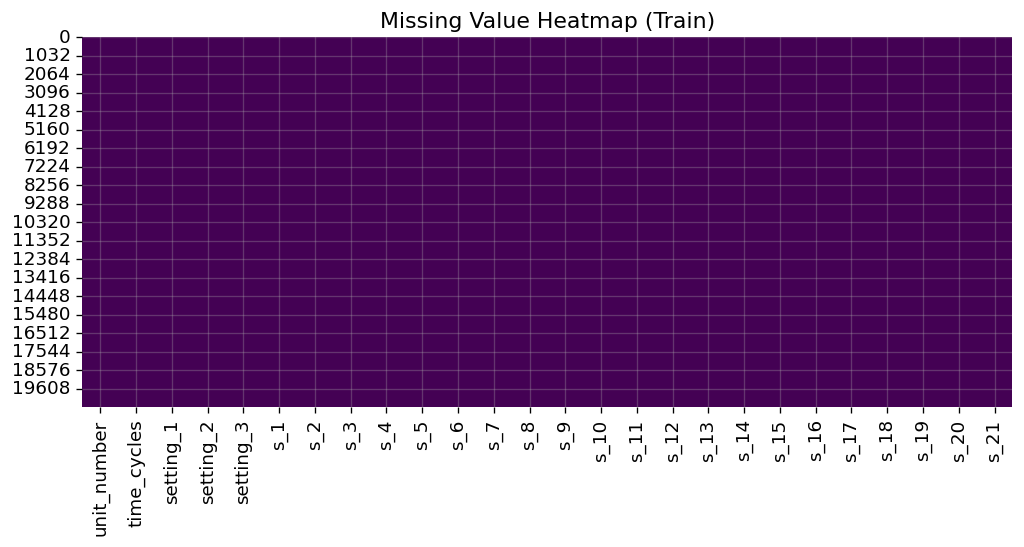

--- Null Counts per Column ---
Series([], dtype: int64)
✅ No missing values detected.


In [4]:
# Diagnostic: Missing Value Heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df_train.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap (Train)')
plt.show()

# Diagnostic: Exact Null Counts
null_counts = df_train.isnull().sum()
print("--- Null Counts per Column ---")
print(null_counts[null_counts > 0])
if null_counts.sum() == 0:
    print("✅ No missing values detected.")

### 1.4 Descriptive Statistics
We examine the statistical properties of the data to catch any obvious anomalies (e.g., negative cycles, impossible sensor readings).

In [5]:
df_train.loc[:,['unit_number','time_cycles']].describe()

,unit_number,time_cycles
count,20631.000000,20631.000000
mean,51.506568,108.807862
std,29.227633,68.880990
min,1.000000,1.000000
25%,26.000000,52.000000
50%,52.000000,104.000000
75%,77.000000,156.000000
max,100.000000,362.000000


When we inspect the descriptive statistics of unit_number we can see the dataset has a total of 20631 rows, unit numbers start at 1 and end at 100 as expected. What’s interesting, is that the **mean and quantiles don’t align neatly** with the descriptive statistics of a vector from 1–100, this can be explained due to **each engine have different max time_cycles and thus a different number of rows**. 
- each engine appears multiple times
- engines run for different numbers of cycles
- engines with longer lifetimes appear more often

In [6]:
print('Shape of the train dataset : ',df_train.shape)
print('Shape of the validation dataset : ',df_test.shape)
print('Percentage of the validation dataset : ',len(df_test)/(len(df_test)+len(df_train)))


Shape of the train dataset :  (20631, 26)
Shape of the validation dataset :  (13096, 26)
Percentage of the validation dataset :  0.3882942449669404


In [7]:
# Diagnostic: Descriptive Statistics
desc_stats = df_train.describe().T
print("--- Descriptive Statistics (Train) ---")
print(desc_stats[['mean', 'std', 'min', 'max']])

# Logic Check: Are time_cycles strictly positive?
if df_train['time_cycles'].min() > 0:
    print("\n✅ Time cycles are strictly positive.")
else:
    print("\n❌ Warning: Found non-positive time cycles.")

--- Descriptive Statistics (Train) ---
                    mean           std        min        max
unit_number    51.506568  2.922763e+01     1.0000   100.0000
time_cycles   108.807862  6.888099e+01     1.0000   362.0000
setting_1      -0.000009  2.187313e-03    -0.0087     0.0087
setting_2       0.000002  2.930621e-04    -0.0006     0.0006
setting_3     100.000000  0.000000e+00   100.0000   100.0000
s_1           518.670000  0.000000e+00   518.6700   518.6700
s_2           642.680934  5.000533e-01   641.2100   644.5300
s_3          1590.523119  6.131150e+00  1571.0400  1616.9100
s_4          1408.933782  9.000605e+00  1382.2500  1441.4900
s_5            14.620000  5.329200e-15    14.6200    14.6200
s_6            21.609803  1.388985e-03    21.6000    21.6100
s_7           553.367711  8.850923e-01   549.8500   556.0600
s_8          2388.096652  7.098548e-02  2387.9000  2388.5600
s_9          9065.242941  2.208288e+01  9021.7300  9244.5900
s_10            1.300000  0.000000e+00     1.3

In [8]:
df_train.loc[:,'s_1':].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
s_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
s_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
s_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
s_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
s_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200
s_6,20631.0,21.609803,1.388985e-03,21.6000,21.6100,21.6100,21.6100,21.6100
s_7,20631.0,553.367711,8.850923e-01,549.8500,552.8100,553.4400,554.0100,556.0600
s_8,20631.0,2388.096652,7.098548e-02,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600
s_9,20631.0,9065.242941,2.208288e+01,9021.7300,9053.1000,9060.6600,9069.4200,9244.5900
s_10,20631.0,1.300000,0.000000e+00,1.3000,1.3000,1.3000,1.3000,1.3000


### 1.5 Ground Truth Loading
Load the RUL ground truth for the test set.

In [9]:
rul_path = DATA_DIR / 'RUL_FD001.txt'
y_test_rul = pd.read_csv(
    rul_path,
    sep=r'\s+', header=None, index_col=False, names=['RUL']
)
print(f"✅ RUL Ground Truth Loaded. Shape: {y_test_rul.shape}")

✅ RUL Ground Truth Loaded. Shape: (100, 1)
